In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("shopping_behavior_updated (2).csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
print("Shape:", df.shape)

Shape: (3900, 18)


In [6]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')


In [7]:
print(df.dtypes)

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
df.describe(include='object')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

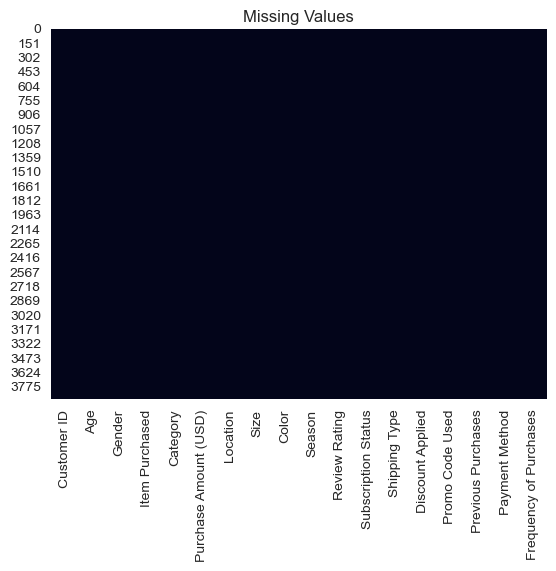

In [12]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases'],
      dtype='object')

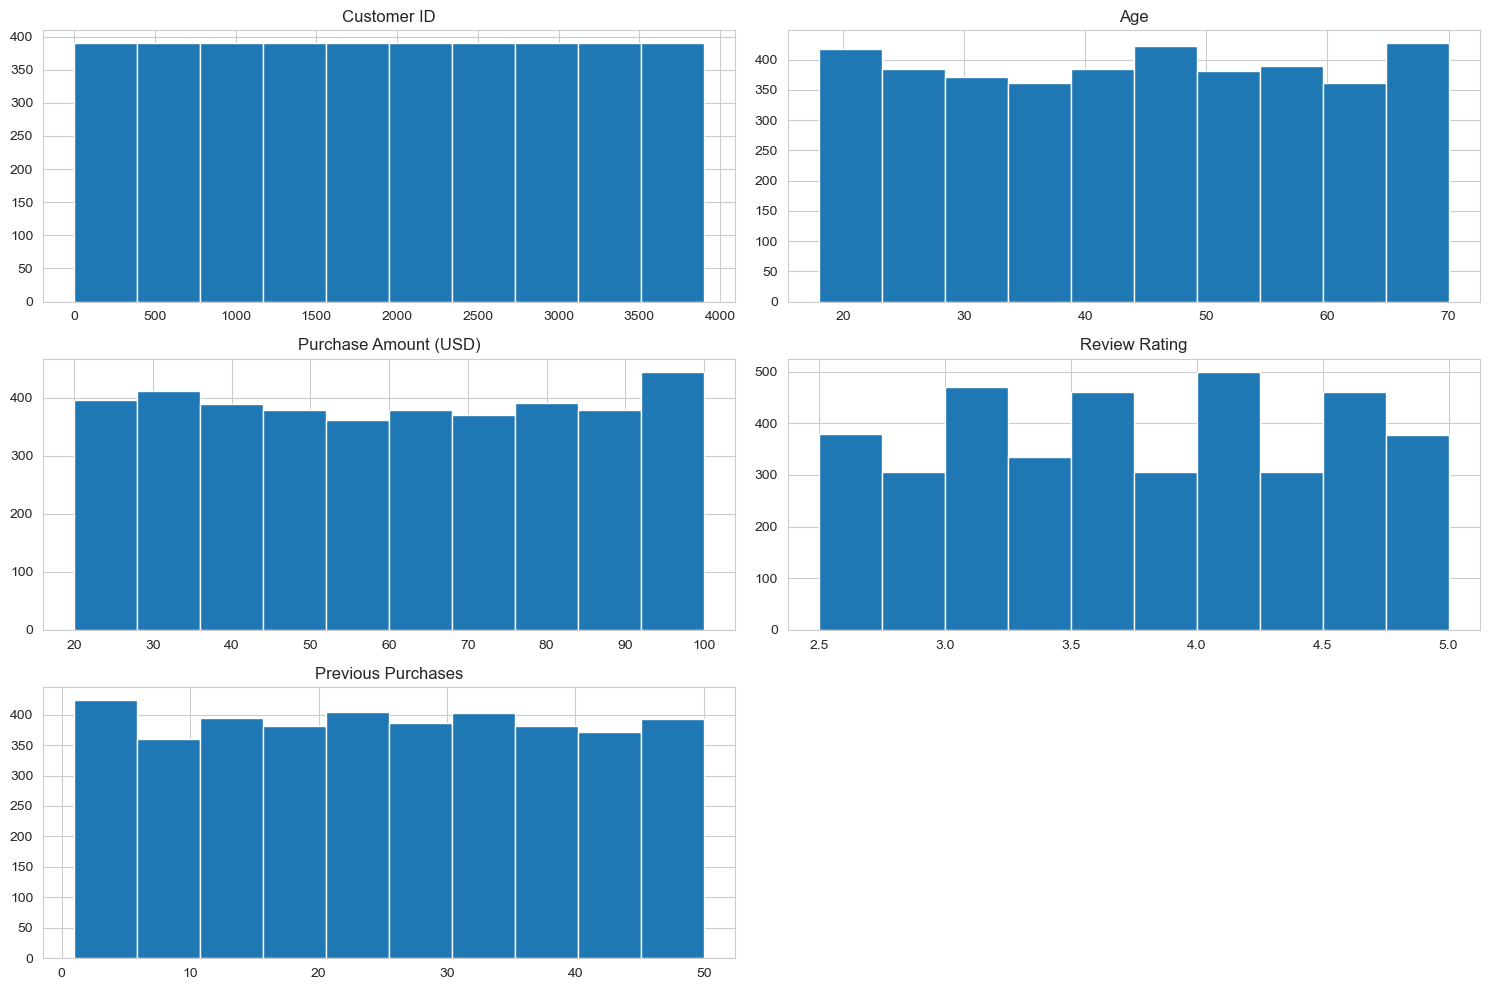

In [16]:
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

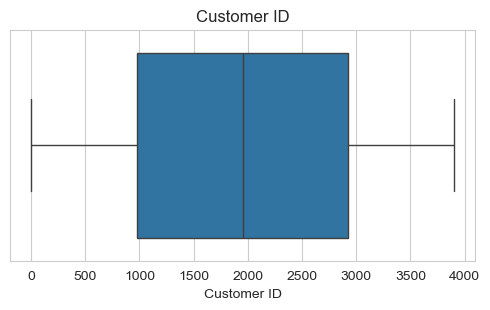

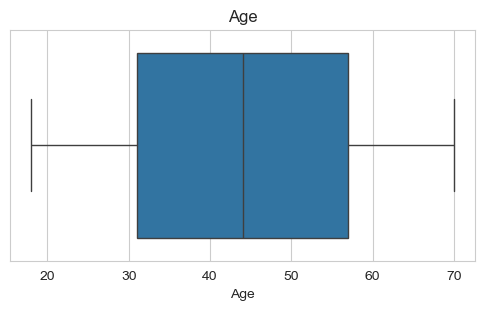

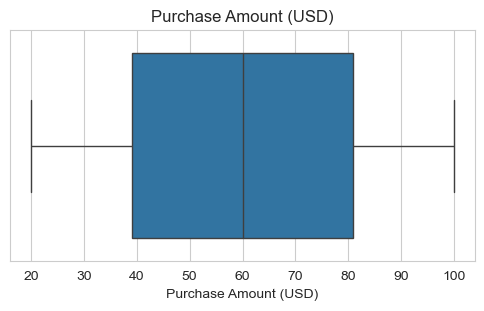

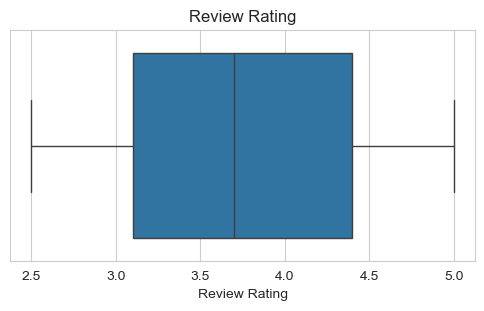

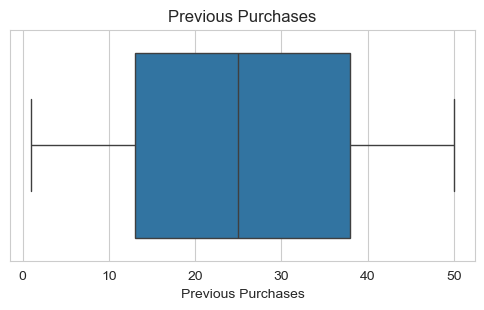

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Payment Method', 'Frequency of Purchases'],
      dtype='object')

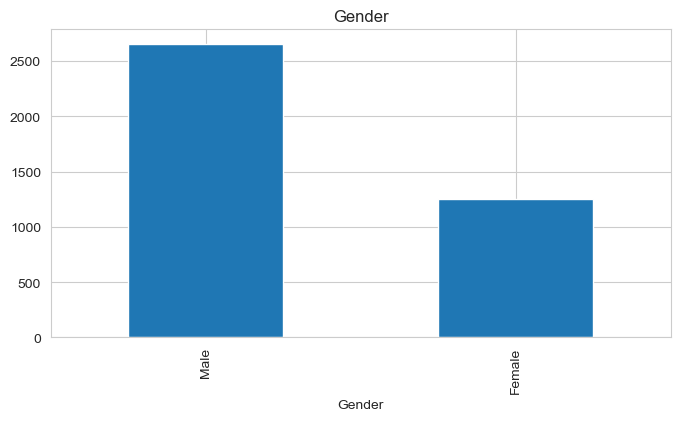

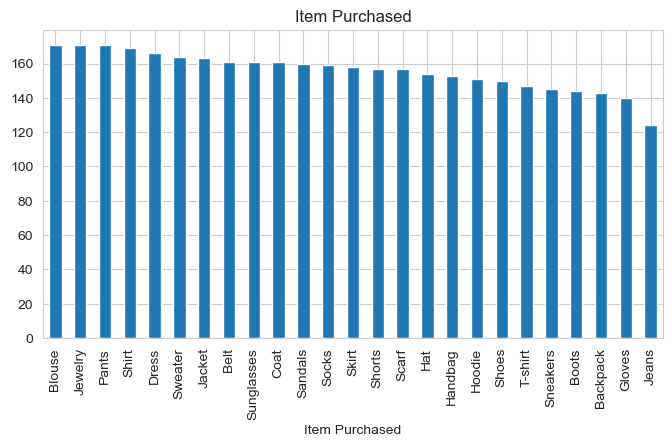

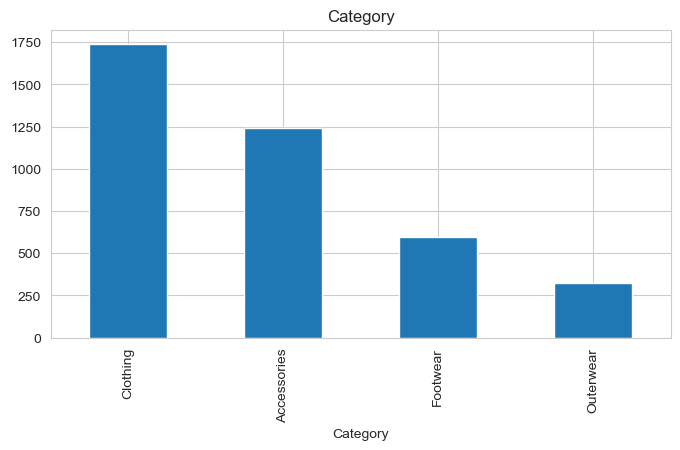

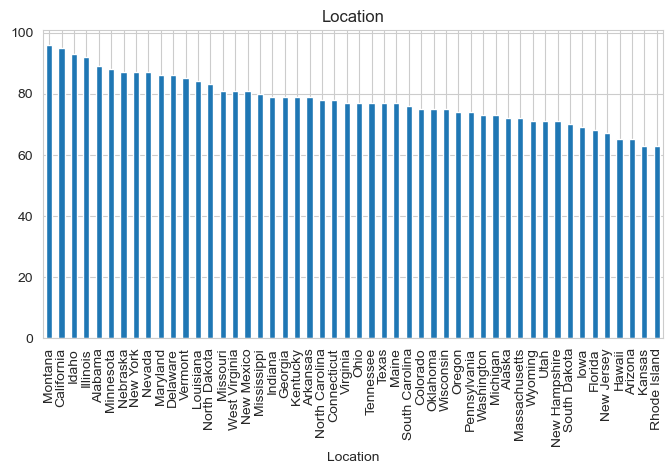

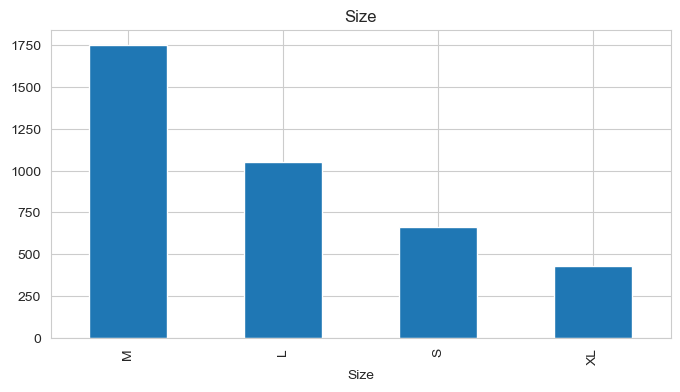

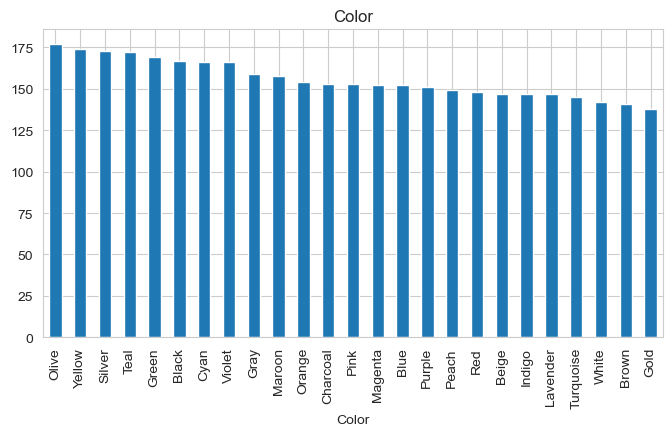

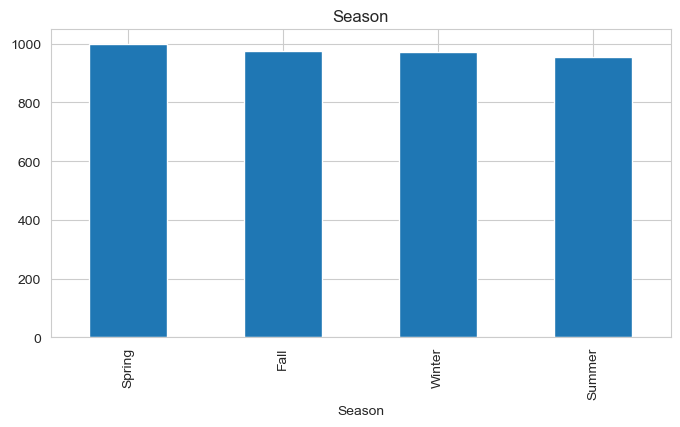

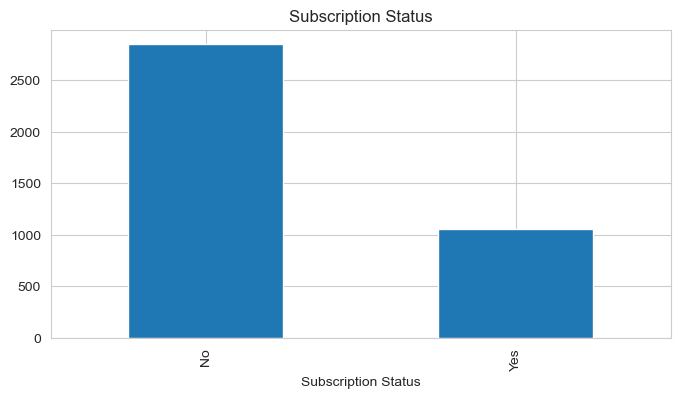

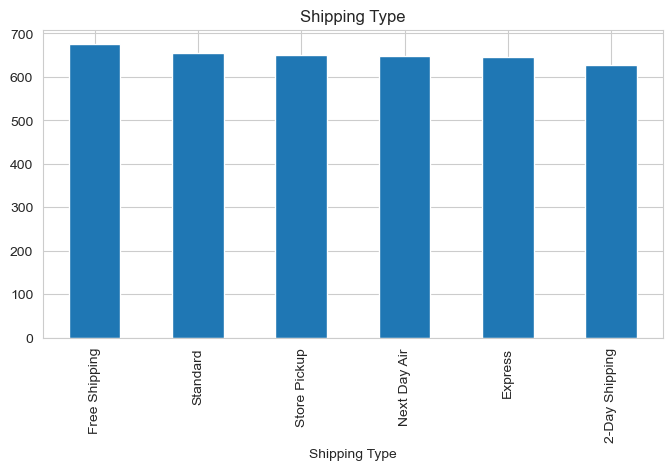

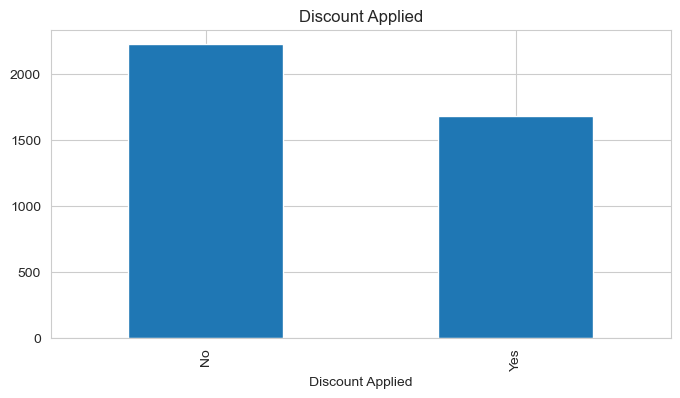

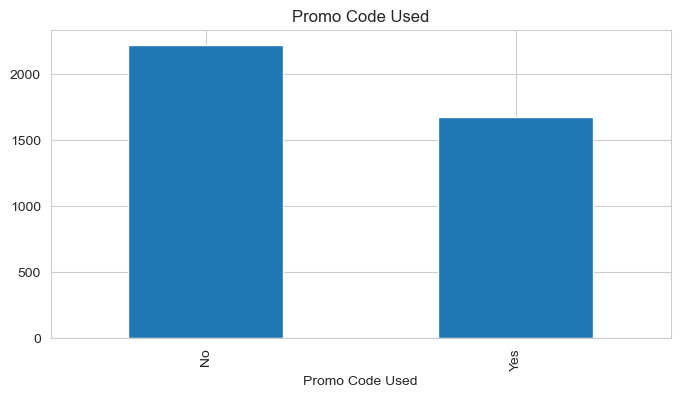

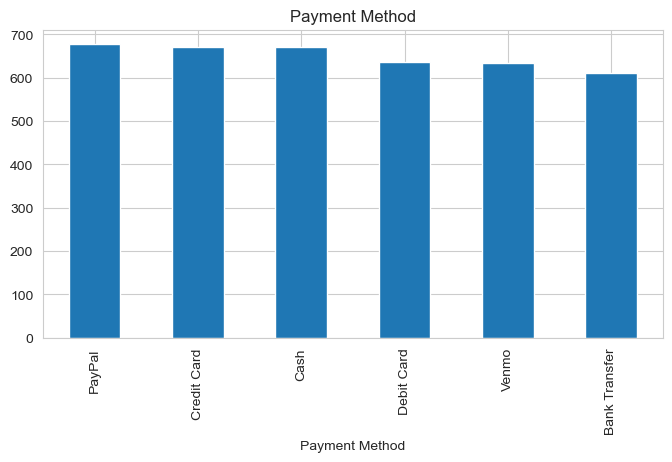

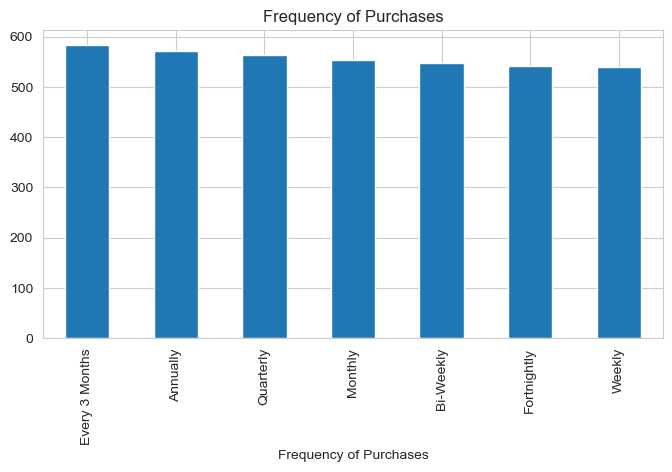

In [19]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

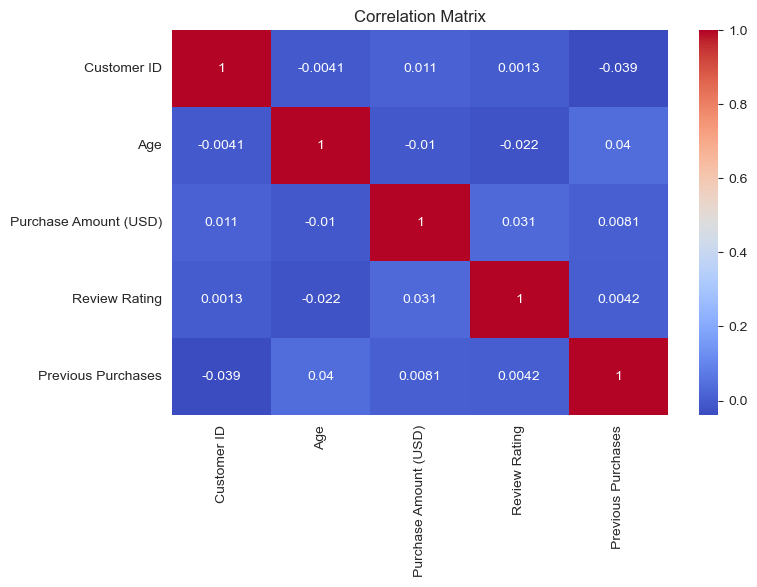

In [20]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

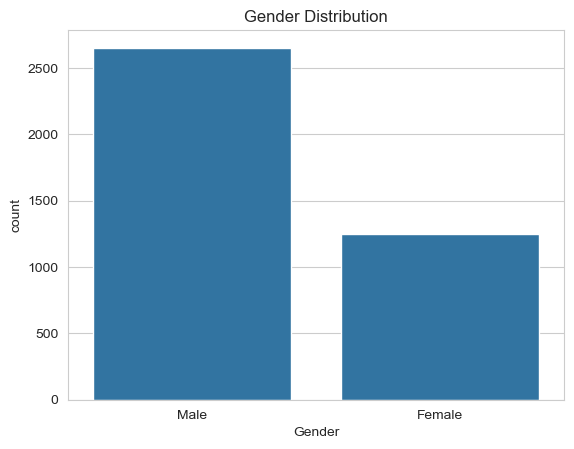

In [21]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

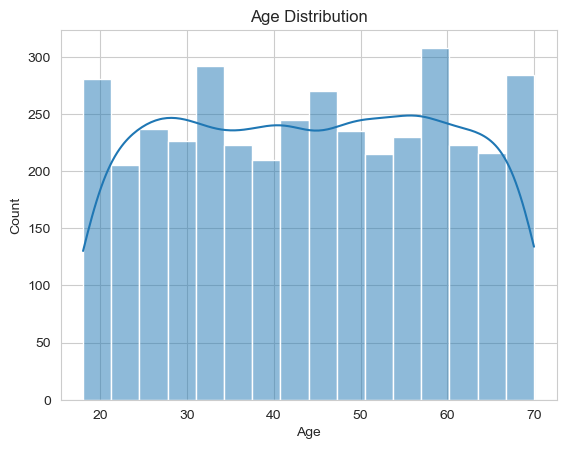

In [22]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [23]:
total_revenue = df['Purchase Amount (USD)'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 233081


In [24]:
df['Purchase Amount (USD)'].mean()

59.76435897435898

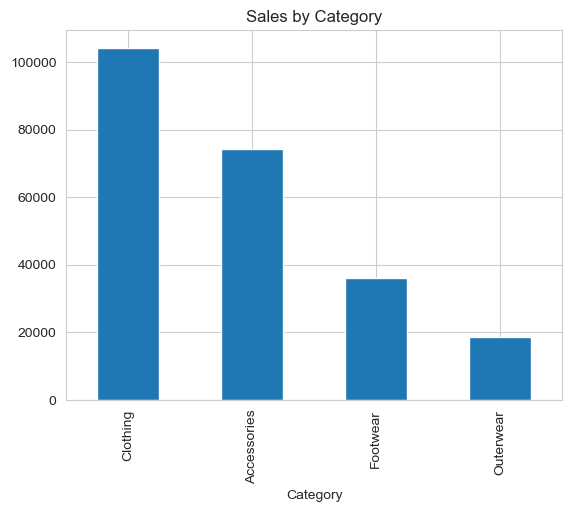

In [25]:
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

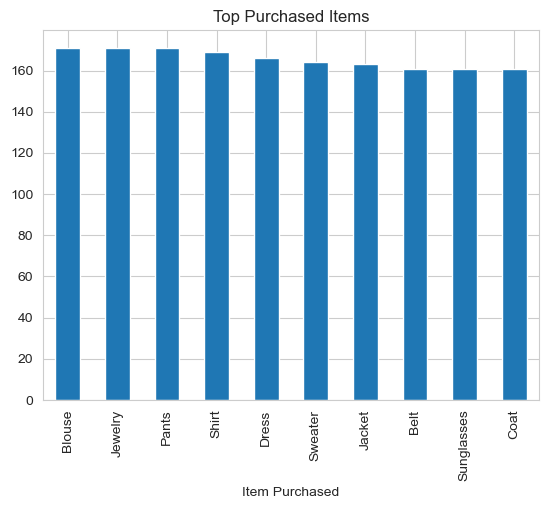

In [26]:
top_items = df['Item Purchased'].value_counts().head(10)

top_items.plot(kind='bar')
plt.title("Top Purchased Items")
plt.show()

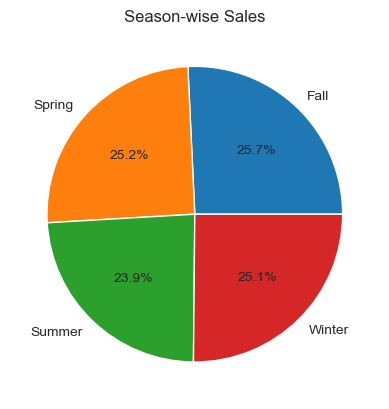

In [27]:
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum()

season_sales.plot(kind='pie',
                  autopct='%1.1f%%')

plt.title("Season-wise Sales")
plt.ylabel("")
plt.show()

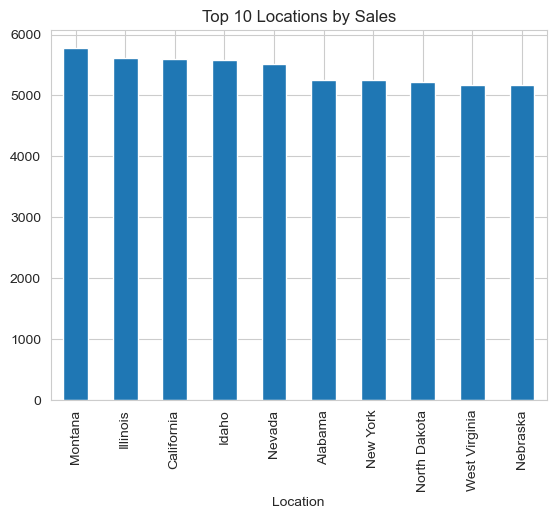

In [28]:
location_sales = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

location_sales.head(10).plot(kind='bar')
plt.title("Top 10 Locations by Sales")
plt.show()

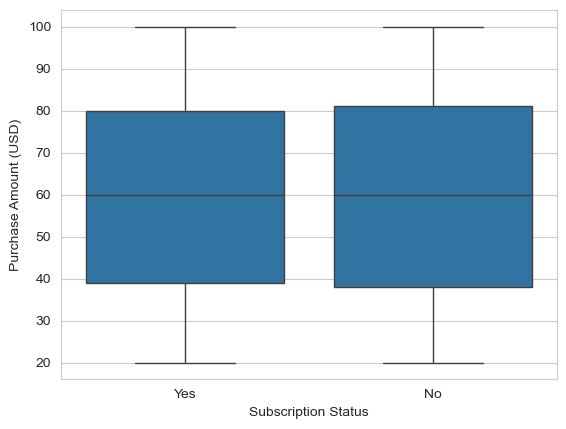

In [29]:
sns.boxplot(x='Subscription Status',
            y='Purchase Amount (USD)',
            data=df)

plt.show()

In [30]:
df.groupby('Subscription Status')['Purchase Amount (USD)'].sum()

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64

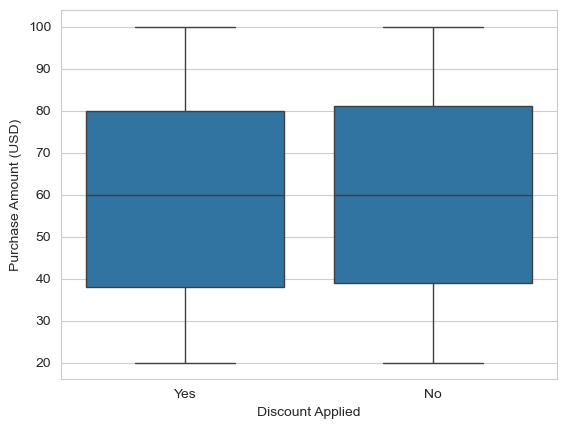

In [31]:
sns.boxplot(
    x='Discount Applied',
    y='Purchase Amount (USD)',
    data=df
)

plt.show()

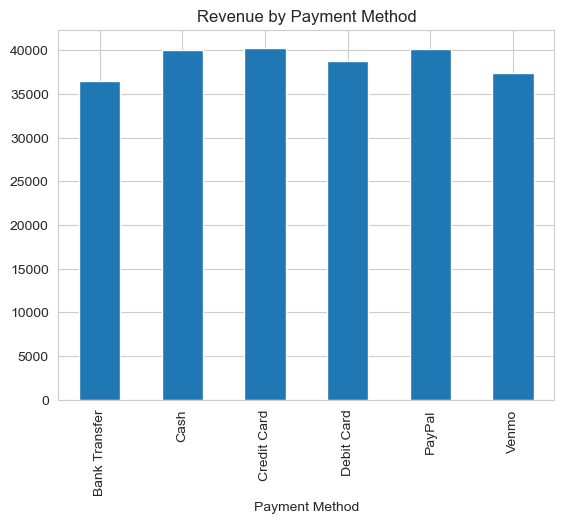

In [32]:
payment_sales = df.groupby('Payment Method')['Purchase Amount (USD)'].sum()

payment_sales.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.show()

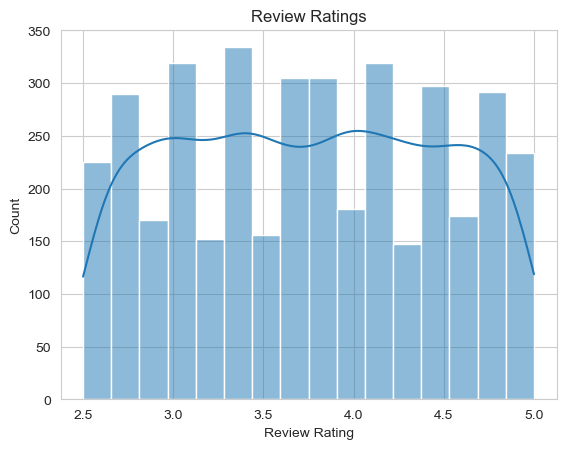

In [33]:
sns.histplot(df['Review Rating'],
             kde=True)

plt.title("Review Ratings")
plt.show()

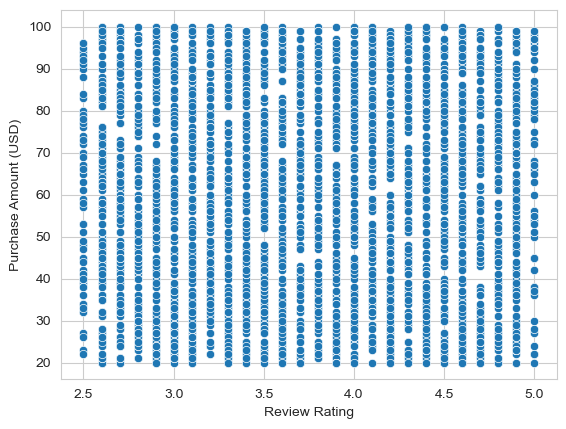

In [34]:
sns.scatterplot(
    x='Review Rating',
    y='Purchase Amount (USD)',
    data=df
)

plt.show()

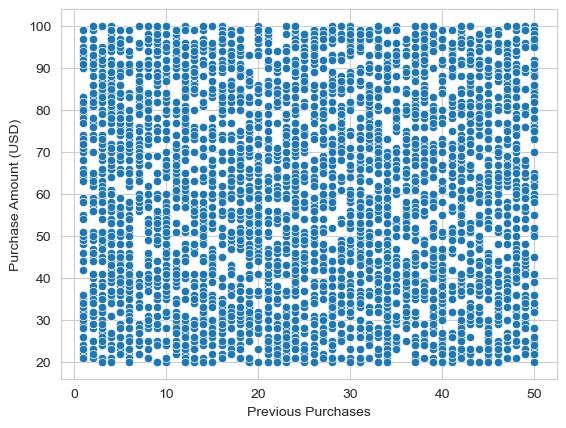

In [35]:
sns.scatterplot(
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    data=df
)

plt.show()

In [36]:
df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

In [37]:
df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

In [38]:
df.groupby('Gender')['Purchase Amount (USD)'].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64

In [39]:
bins = [0,20,30,40,50,60,100]

labels = ['<20','20-30','30-40','40-50','50-60','60+']

df['Age_Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

df.groupby('Age_Group')['Purchase Amount (USD)'].sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_12292\543105436.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Purchase Amount (USD)'].sum()


Age_Group
<20      12504
20-30    44775
30-40    43193
40-50    44129
50-60    45316
60+      43164
Name: Purchase Amount (USD), dtype: int64

In [40]:
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()

print(outliers)

Customer ID              0
Age                      0
Purchase Amount (USD)    0
Review Rating            0
Previous Purchases       0
dtype: int64


In [41]:
print("Total Customers :", df.shape[0])

print("Total Revenue :", df['Purchase Amount (USD)'].sum())

print("Average Purchase :", df['Purchase Amount (USD)'].mean())

print("Highest Selling Category :",
      df.groupby('Category')['Purchase Amount (USD)']
      .sum()
      .idxmax())

print("Best Season :",
      df.groupby('Season')['Purchase Amount (USD)']
      .sum()
      .idxmax())

Total Customers : 3900
Total Revenue : 233081
Average Purchase : 59.76435897435898
Highest Selling Category : Clothing
Best Season : Fall
